In [1]:
import os
import json
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader, random_split

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

results = []
os.makedirs("artifacts/figures", exist_ok=True)

device: cuda


## Часть A (S10): Классификация изображений — STL10

In [2]:
base_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

aug_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(96, padding=4),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

resnet_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

In [3]:
# Базовые датасеты (transform можно менять через Subset-обёртку или напрямую)
full_train_base = datasets.STL10(root="./data", split="train", download=True, transform=base_tf)
full_train_aug  = datasets.STL10(root="./data", split="train", download=True, transform=aug_tf)
full_train_res  = datasets.STL10(root="./data", split="train", download=True, transform=resnet_tf)
test_base       = datasets.STL10(root="./data", split="test",  download=True, transform=base_tf)
test_res        = datasets.STL10(root="./data", split="test",  download=True, transform=resnet_tf)

train_size = int(0.8 * len(full_train_base))
val_size   = len(full_train_base) - train_size
generator  = torch.Generator().manual_seed(SEED)

indices = torch.randperm(len(full_train_base), generator=generator).tolist()
train_idx, val_idx = indices[:train_size], indices[train_size:]

from torch.utils.data import Subset

# Для каждого эксперимента — свой train-сплит; val всегда base_tf
train_base = Subset(full_train_base, train_idx)
val_base   = Subset(full_train_base, val_idx)

train_aug  = Subset(full_train_aug,  train_idx)
# val для C2 тоже base (корректное сравнение!)

train_res  = Subset(full_train_res,  train_idx)
val_res    = Subset(full_train_res,  val_idx)
test_res_loader = DataLoader(test_res, batch_size=64)

def make_loaders(train_ds, val_ds, test_ds, bs=64):
    return (DataLoader(train_ds, batch_size=bs, shuffle=True),
            DataLoader(val_ds,   batch_size=bs),
            DataLoader(test_ds,  batch_size=bs))

loaders_base = make_loaders(train_base, val_base, test_base)
loaders_aug  = make_loaders(train_aug,  val_base, test_base)   # val всегда base!
loaders_res  = make_loaders(train_res,  val_res,  test_res)

print(f"Train: {len(train_base)}, Val: {len(val_base)}, Test: {len(test_base)}")

100.0%


Extracting ./data\stl10_binary.tar.gz to ./data
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Train: 4000, Val: 1000, Test: 8000


x.shape: torch.Size([64, 3, 96, 96]) | y.shape: torch.Size([64])


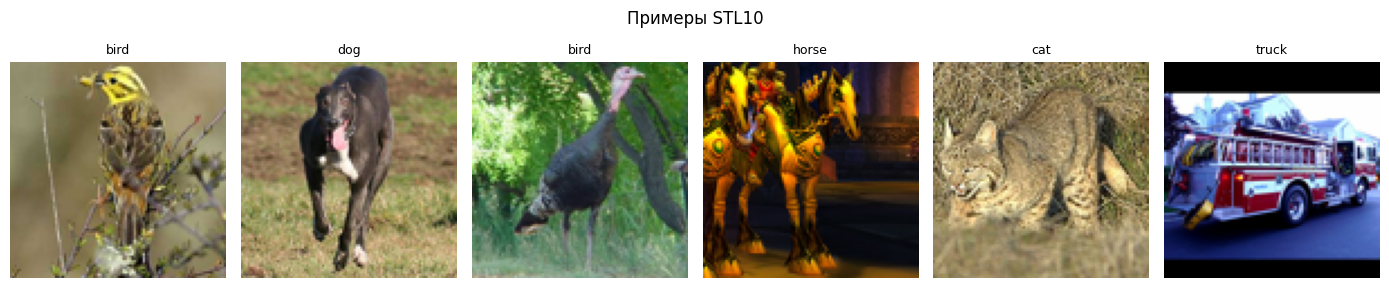

In [4]:
# Sanity-check
x, y = next(iter(loaders_base[0]))
print("x.shape:", x.shape, "| y.shape:", y.shape)

classes = full_train_base.classes
fig, axes = plt.subplots(1, 6, figsize=(14, 3))
for ax, (img, lbl) in zip(axes, [full_train_base[i] for i in range(6)]):
    img_show = img.permute(1,2,0).numpy()
    img_show = (img_show * 0.5 + 0.5).clip(0,1)
    ax.imshow(img_show)
    ax.set_title(classes[lbl], fontsize=9)
    ax.axis("off")
plt.suptitle("Примеры STL10")
plt.tight_layout()
plt.savefig("artifacts/figures/sanity_check.png")
plt.show()

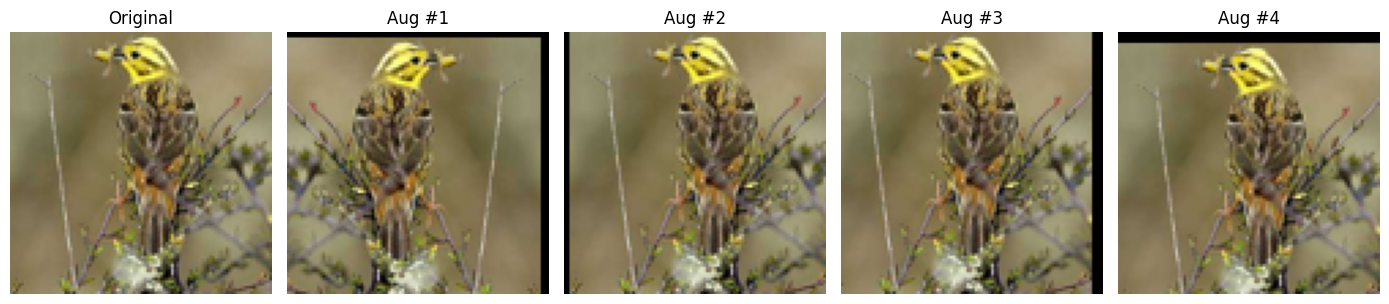

In [5]:
# Визуализация аугментаций
img_raw, _ = full_train_base[0]   # после base_tf: [C,H,W] normalized
# Восстановим PIL из base_tf тензора
img_pil = transforms.ToPILImage()(img_raw * 0.5 + 0.5)

fig, axes = plt.subplots(1, 5, figsize=(14, 3))
axes[0].imshow(img_pil); axes[0].set_title("Original"); axes[0].axis("off")
for i in range(1, 5):
    aug_t = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(96, padding=4),
    ])(img_pil)
    axes[i].imshow(aug_t); axes[i].set_title(f"Aug #{i}"); axes[i].axis("off")

plt.tight_layout()
plt.savefig("artifacts/figures/augmentations_preview.png")
plt.show()

In [6]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64*24*24, 128), nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    def forward(self, x): return self.net(x)

def get_resnet18_head(num_classes=10):
    model = models.resnet18(weights="IMAGENET1K_V1")
    for p in model.parameters():
        p.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def get_resnet18_ft(num_classes=10):
    model = models.resnet18(weights="IMAGENET1K_V1")
    for name, p in model.named_parameters():
        if "layer4" not in name and "fc" not in name:
            p.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

In [7]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)
    return total_loss / len(loader), correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            total_loss += loss.item()
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
    return total_loss / len(loader), correct / total

In [8]:
def run_exp(exp_id, model, train_loader, val_loader, notes, epochs=5):
    model.to(device)
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    best_val, best_state = 0.0, None

    for epoch in range(epochs):
        tl, ta = train_one_epoch(model, train_loader, optimizer, criterion)
        vl, va = evaluate(model, val_loader, criterion)
        train_losses.append(tl); val_losses.append(vl)
        train_accs.append(ta);   val_accs.append(va)
        print(f"[{exp_id}] Epoch {epoch+1}/{epochs} | "
              f"train_loss={tl:.3f} acc={ta:.3f} | val_loss={vl:.3f} acc={va:.3f}")
        if va > best_val:
            best_val = va
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    return {
        "exp_id": exp_id, "notes": notes,
        "best_val": best_val, "best_state": best_state,
        "train_losses": train_losses, "val_losses": val_losses,
        "train_accs": train_accs, "val_accs": val_accs,
    }

In [9]:
torch.manual_seed(SEED); np.random.seed(SEED)
res_c1 = run_exp("C1", SimpleCNN(),        *loaders_base[:2], notes="no aug")
torch.manual_seed(SEED); np.random.seed(SEED)
res_c2 = run_exp("C2", SimpleCNN(),        loaders_aug[0], loaders_base[1], notes="aug")
torch.manual_seed(SEED); np.random.seed(SEED)
res_c3 = run_exp("C3", get_resnet18_head(), *loaders_res[:2], notes="head only")
torch.manual_seed(SEED); np.random.seed(SEED)
res_c4 = run_exp("C4", get_resnet18_ft(),  *loaders_res[:2], notes="finetune")

exp_results = [res_c1, res_c2, res_c3, res_c4]

[C1] Epoch 1/5 | train_loss=1.898 acc=0.309 | val_loss=1.544 acc=0.401
[C1] Epoch 2/5 | train_loss=1.375 acc=0.497 | val_loss=1.404 acc=0.487
[C1] Epoch 3/5 | train_loss=1.088 acc=0.615 | val_loss=1.472 acc=0.463
[C1] Epoch 4/5 | train_loss=0.809 acc=0.710 | val_loss=1.497 acc=0.520
[C1] Epoch 5/5 | train_loss=0.498 acc=0.838 | val_loss=1.617 acc=0.534
[C2] Epoch 1/5 | train_loss=1.978 acc=0.269 | val_loss=1.620 acc=0.395
[C2] Epoch 2/5 | train_loss=1.554 acc=0.432 | val_loss=1.421 acc=0.480
[C2] Epoch 3/5 | train_loss=1.400 acc=0.490 | val_loss=1.362 acc=0.505
[C2] Epoch 4/5 | train_loss=1.270 acc=0.533 | val_loss=1.386 acc=0.505
[C2] Epoch 5/5 | train_loss=1.211 acc=0.557 | val_loss=1.232 acc=0.551
[C3] Epoch 1/5 | train_loss=1.019 acc=0.750 | val_loss=0.428 acc=0.913
[C3] Epoch 2/5 | train_loss=0.341 acc=0.931 | val_loss=0.288 acc=0.935
[C3] Epoch 3/5 | train_loss=0.249 acc=0.941 | val_loss=0.240 acc=0.938
[C3] Epoch 4/5 | train_loss=0.213 acc=0.943 | val_loss=0.220 acc=0.934
[C3] E

In [10]:
# Выбор лучшей модели по best_val_accuracy
best_exp = max(exp_results, key=lambda r: r["best_val"])
print(f"Лучшая модель: {best_exp['exp_id']} (val_acc={best_exp['best_val']:.4f})")

# Финальная оценка на тесте — только один раз, только лучшей моделью
if best_exp["exp_id"] in ("C1", "C2"):
    best_model = SimpleCNN()
    test_loader_final = loaders_base[2]
else:
    best_model = get_resnet18_ft() if best_exp["exp_id"] == "C4" else get_resnet18_head()
    test_loader_final = loaders_res[2]

best_model.load_state_dict(best_exp["best_state"])
best_model.to(device)
criterion_test = nn.CrossEntropyLoss()
_, test_acc = evaluate(best_model, test_loader_final, criterion_test)
print(f"Test accuracy лучшей модели ({best_exp['exp_id']}): {test_acc:.4f}")

# Сохранение весов и конфига
torch.save(best_exp["best_state"], "artifacts/best_classifier.pt")

config = {
    "experiment_id": best_exp["exp_id"],
    "dataset": "STL10",
    "model": best_exp["exp_id"],
    "notes": best_exp["notes"],
    "lr": 1e-3,
    "epochs": 5,
    "batch_size": 64,
    "seed": SEED,
    "transforms": {
        "C1": "ToTensor + Normalize(0.5)",
        "C2": "RandomHFlip + RandomCrop + ToTensor + Normalize(0.5)",
        "C3": "Resize(224) + ToTensor + Normalize(ImageNet)",
        "C4": "Resize(224) + ToTensor + Normalize(ImageNet)",
    }[best_exp["exp_id"]],
    "best_val_accuracy": best_exp["best_val"],
    "test_accuracy": float(test_acc),
}
with open("artifacts/best_classifier_config.json", "w") as f:
    json.dump(config, f, indent=2)
print("Сохранено: best_classifier.pt, best_classifier_config.json")

Лучшая модель: C3 (val_acc=0.9410)
Test accuracy лучшей модели (C3): 0.9430
Сохранено: best_classifier.pt, best_classifier_config.json


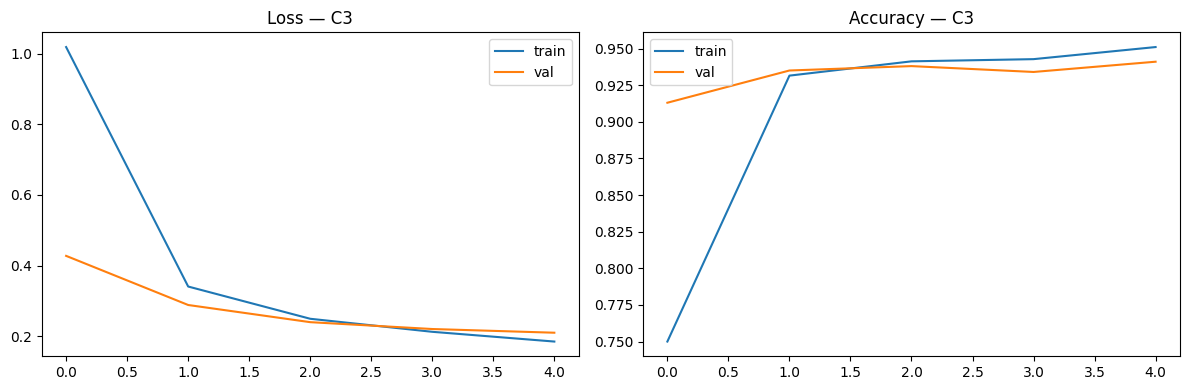

In [11]:
# График loss/accuracy для лучшего прогона
r = best_exp
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(r["train_losses"], label="train"); ax1.plot(r["val_losses"], label="val")
ax1.set_title(f"Loss — {r['exp_id']}"); ax1.legend()
ax2.plot(r["train_accs"], label="train"); ax2.plot(r["val_accs"], label="val")
ax2.set_title(f"Accuracy — {r['exp_id']}"); ax2.legend()
plt.tight_layout()
plt.savefig("artifacts/figures/classification_curves_best.png")
plt.show()

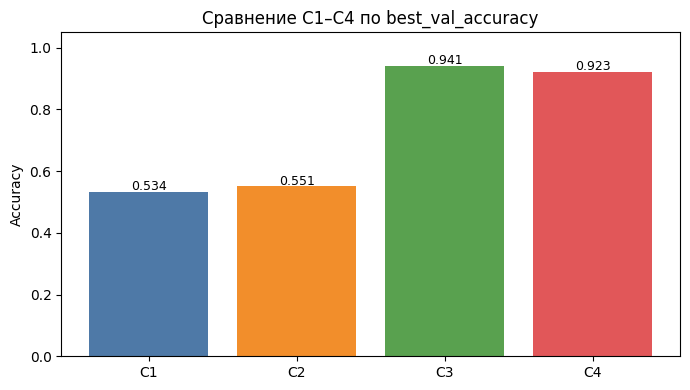

In [12]:
# Сравнение C1-C4
labels = [r["exp_id"] for r in exp_results]
vals   = [r["best_val"] for r in exp_results]
plt.figure(figsize=(7, 4))
bars = plt.bar(labels, vals, color=["#4e79a7","#f28e2b","#59a14f","#e15759"])
for bar, v in zip(bars, vals):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)
plt.title("Сравнение C1–C4 по best_val_accuracy")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig("artifacts/figures/classification_compare.png")
plt.show()

In [13]:
# Запись результатов части A
best_ids = {r["exp_id"] for r in exp_results}
for r in exp_results:
    results.append({
        "experiment_id": r["exp_id"],
        "task": "classification",
        "dataset": "STL10",
        "seed": SEED,
        "model_summary": {"C1":"SimpleCNN","C2":"SimpleCNN","C3":"ResNet18-head","C4":"ResNet18-ft"}[r["exp_id"]],
        "optimizer": "Adam",
        "lr": 1e-3,
        "epochs_trained": 5,
        "best_val_accuracy": round(r["best_val"], 4),
        "test_accuracy": round(float(test_acc), 4) if r["exp_id"] == best_exp["exp_id"] else "",
        "precision": "",
        "recall": "",
        "mean_iou": "",
        "notes": r["notes"],
    })

## Часть B (S11): Сегментация — VOC 2012 (DeepLabV3)

V1 = базовая постобработка (argmax). V2 = альтернативная (удаление мелких компонент).

In [14]:
seg_tf_img = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

seg_dataset = datasets.VOCSegmentation(
    root="./data", year="2012", image_set="val", download=True
)

seg_model = models.segmentation.deeplabv3_resnet50(weights="DEFAULT").to(device)
seg_model.eval()
print("Сегментационная модель загружена")

100.0%


Extracting ./data\VOCtrainval_11-May-2012.tar to ./data
Сегментационная модель загружена


In [15]:
def compute_iou(pred, target):
    pred, target = pred.bool(), target.bool()
    inter = (pred & target).sum().float()
    union = (pred | target).sum().float()
    return float(inter / union) if union > 0 else float("nan")

def compute_pixel_metrics(pred, target):
    pred, target = pred.bool(), target.bool()
    tp = (pred & target).sum().float()
    fp = (pred & ~target).sum().float()
    fn = (~pred & target).sum().float()
    precision = float(tp / (tp + fp)) if (tp + fp) > 0 else float("nan")
    recall    = float(tp / (tp + fn)) if (tp + fn) > 0 else float("nan")
    return precision, recall

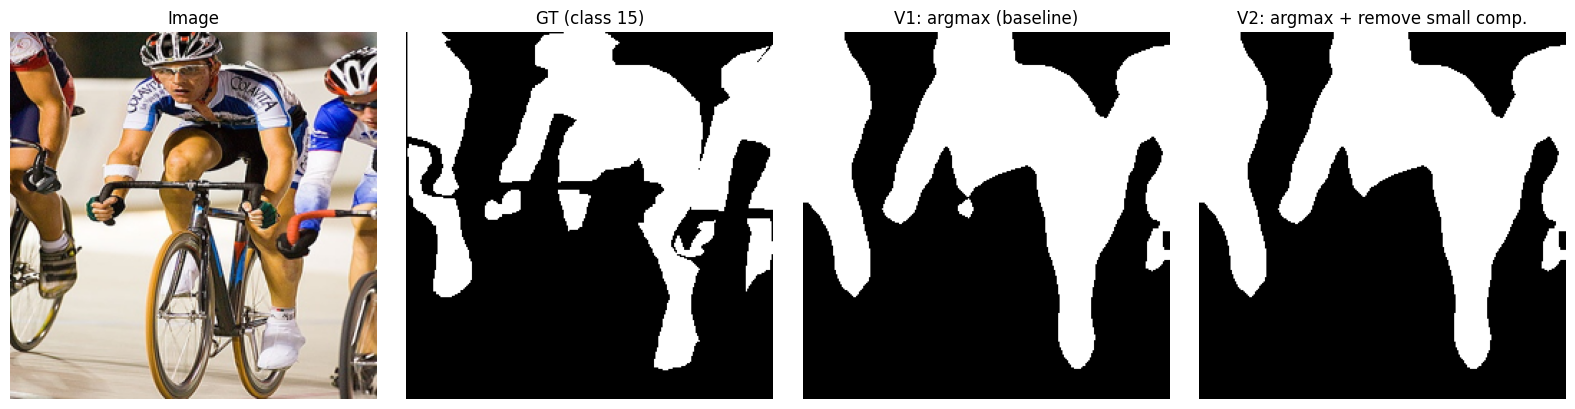

Обработано изображений: 1 (с foreground class 15 = person)


In [16]:
from scipy import ndimage

# === Часть B: Сегментация VOC 2012, датасет: VOC ===
# Foreground: класс 15 (person) по VOC-палитре
# V1: базовая постобработка — argmax по logits, бинаризация по foreground-классу
# V2: альтернативная постобработка — argmax + удаление связных компонент < MIN_COMPONENT_SIZE пикселей

N_SAMPLES = 5
FOREGROUND_CLASS = 15   # 'person' в VOC palette
TARGET_SIZE = (256, 256)
MIN_COMPONENT_SIZE = 500  # порог для постобработки V2

ious_v1, ious_v2 = [], []
prec_v1, rec_v1  = [], []
prec_v2, rec_v2  = [], []

example_saved = False

for i in range(min(N_SAMPLES, len(seg_dataset))):
    img_pil, target_pil = seg_dataset[i]

    x = seg_tf_img(img_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = seg_model(x)["out"]  # [1, C, H, W]

    pred_full = logits.argmax(1)[0].cpu()  # [H, W] — argmax по классам

    # Подготовка ground truth маски
    target_np = np.array(target_pil.resize(TARGET_SIZE, Image.NEAREST))
    target_t  = torch.from_numpy(target_np.copy())
    target_t[target_t == 255] = 0  # ignore label → background

    fg_target = (target_t == FOREGROUND_CLASS)
    if fg_target.sum() == 0:
        continue  # foreground-класс отсутствует на изображении — пропускаем

    # --- V1: базовая постобработка маски ---
    # Бинаризация: пиксели где argmax == FOREGROUND_CLASS считаются foreground
    pred_v1 = (pred_full == FOREGROUND_CLASS)

    # --- V2: альтернативная постобработка маски ---
    # Дополнительно удаляем связные компоненты площадью < MIN_COMPONENT_SIZE пикселей
    pred_v2_np = pred_v1.numpy().astype(np.uint8)
    labeled, n_comp = ndimage.label(pred_v2_np)
    for comp in range(1, n_comp + 1):
        if (labeled == comp).sum() < MIN_COMPONENT_SIZE:
            pred_v2_np[labeled == comp] = 0  # удаляем шумовую компоненту
    pred_v2 = torch.from_numpy(pred_v2_np).bool()

    # Метрики для V1
    ious_v1.append(compute_iou(pred_v1, fg_target))
    p1, r1 = compute_pixel_metrics(pred_v1, fg_target)
    prec_v1.append(p1); rec_v1.append(r1)

    # Метрики для V2
    ious_v2.append(compute_iou(pred_v2, fg_target))
    p2, r2 = compute_pixel_metrics(pred_v2, fg_target)
    prec_v2.append(p2); rec_v2.append(r2)

    # Визуализация первого подходящего примера
    if not example_saved:
        fig, axes = plt.subplots(1, 4, figsize=(16, 4))
        img_show = np.array(img_pil.resize(TARGET_SIZE))
        axes[0].imshow(img_show); axes[0].set_title("Image"); axes[0].axis("off")
        axes[1].imshow(fg_target.numpy(), cmap="gray"); axes[1].set_title(f"GT (class {FOREGROUND_CLASS})"); axes[1].axis("off")
        axes[2].imshow(pred_v1.numpy(), cmap="gray"); axes[2].set_title("V1: argmax (baseline)"); axes[2].axis("off")
        axes[3].imshow(pred_v2.numpy(), cmap="gray"); axes[3].set_title("V2: argmax + remove small comp."); axes[3].axis("off")
        plt.tight_layout()
        plt.savefig("artifacts/figures/segmentation_examples.png")
        plt.show()
        example_saved = True

print(f"Обработано изображений: {len(ious_v1)} (с foreground class {FOREGROUND_CLASS} = person)")


V1 — mean_iou=0.8188  precision=0.8538  recall=0.9523
V2 — mean_iou=0.8157  precision=0.8535  recall=0.9485


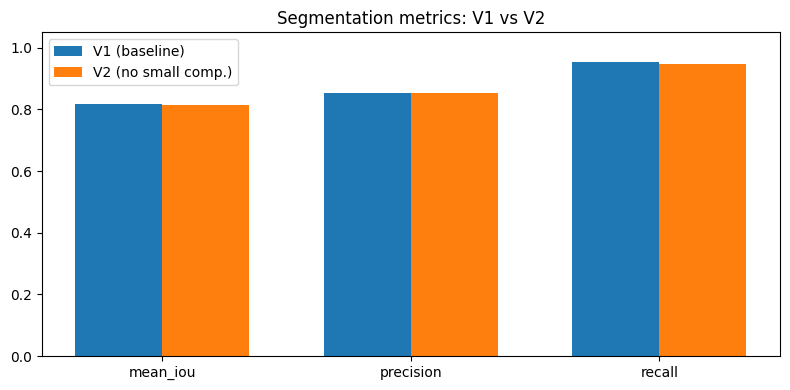

In [17]:
def safe_mean(lst):
    vals = [v for v in lst if not np.isnan(v)]
    return float(np.mean(vals)) if vals else float("nan")

mean_iou_v1 = safe_mean(ious_v1)
mean_iou_v2 = safe_mean(ious_v2)
mean_prec_v1, mean_rec_v1 = safe_mean(prec_v1), safe_mean(rec_v1)
mean_prec_v2, mean_rec_v2 = safe_mean(prec_v2), safe_mean(rec_v2)

print(f"V1 — mean_iou={mean_iou_v1:.4f}  precision={mean_prec_v1:.4f}  recall={mean_rec_v1:.4f}")
print(f"V2 — mean_iou={mean_iou_v2:.4f}  precision={mean_prec_v2:.4f}  recall={mean_rec_v2:.4f}")

metrics = ["mean_iou", "precision", "recall"]
v1_vals = [mean_iou_v1, mean_prec_v1, mean_rec_v1]
v2_vals = [mean_iou_v2, mean_prec_v2, mean_rec_v2]

x = np.arange(len(metrics))
w = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w/2, v1_vals, w, label="V1 (baseline)")
ax.bar(x + w/2, v2_vals, w, label="V2 (no small comp.)")
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.set_title("Segmentation metrics: V1 vs V2")
ax.legend()
plt.tight_layout()
plt.savefig("artifacts/figures/segmentation_metrics.png")
plt.show()

In [18]:
results.append({
    "experiment_id": "V1",
    "task": "segmentation",
    "dataset": "VOC",
    "seed": SEED,
    "model_summary": "DeepLabV3_ResNet50",
    "optimizer": "",
    "lr": "",
    "epochs_trained": "",
    "best_val_accuracy": "",
    "test_accuracy": "",
    "precision": round(mean_prec_v1, 4),
    "recall": round(mean_rec_v1, 4),
    "mean_iou": round(mean_iou_v1, 4),
    "notes": f"baseline argmax, foreground=class{FOREGROUND_CLASS}(person)",
})

results.append({
    "experiment_id": "V2",
    "task": "segmentation",
    "dataset": "VOC",
    "seed": SEED,
    "model_summary": "DeepLabV3_ResNet50",
    "optimizer": "",
    "lr": "",
    "epochs_trained": "",
    "best_val_accuracy": "",
    "test_accuracy": "",
    "precision": round(mean_prec_v2, 4),
    "recall": round(mean_rec_v2, 4),
    "mean_iou": round(mean_iou_v2, 4),
    "notes": f"alt: remove components < {MIN_COMPONENT_SIZE}px, foreground=class{FOREGROUND_CLASS}(person)",
})

df = pd.DataFrame(results)
df.to_csv("artifacts/runs.csv", index=False)
print(df.to_string())

  experiment_id            task dataset  seed       model_summary optimizer     lr epochs_trained best_val_accuracy test_accuracy precision  recall mean_iou                                                       notes
0            C1  classification   STL10    42           SimpleCNN      Adam  0.001              5             0.534                                                                                               no aug
1            C2  classification   STL10    42           SimpleCNN      Adam  0.001              5             0.551                                                                                                  aug
2            C3  classification   STL10    42       ResNet18-head      Adam  0.001              5             0.941         0.943                                                                              head only
3            C4  classification   STL10    42         ResNet18-ft      Adam  0.001              5             0.923                 